# Etapa 4 - Correlação entre Variáveis

Nesta etapa será analisada a relação entre as variáveis climáticas do conjunto de dados.

Serão calculados:

- Coeficientes de correlação de Pearson
- Modelos de regressão linear

Os pares analisados serão:

- Radiação × Temperatura
- Radiação × Evapotranspiração
- Radiação × Precipitação
- Temperatura × Evapotranspiração
- Temperatura × Precipitação
- Precipitação × Evapotranspiração

O objetivo é identificar quais variáveis apresentam maior relação com a radiação solar, fator importante para o potencial fotovoltaico.

In [10]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

In [11]:
sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

In [12]:
file_path = "../data/raw/Dados climáticos de 1984 a 2014 - Formatado.xlsx"

In [13]:
dados = pd.read_excel(file_path, sheet_name="dados")

In [14]:
dados.head()

,Data,mm/dia - Precipitação,mm/dia - Evapotranspiração,C° - Temperatura Média,W/m² - Radiação
0,1984-01-01,0.989776,0.518743,25.419519,211.801254
1,1984-01-02,0.166336,0.587044,26.399133,204.752853
2,1984-01-03,0.256648,0.419522,26.202539,217.430527
3,1984-01-04,0.000000,0.478503,26.720331,222.075912
4,1984-01-05,0.000000,0.374592,27.286249,220.100525


In [15]:
dados.columns.tolist()

['Data',
 'mm/dia - Precipitação',
 'mm/dia - Evapotranspiração ',
 'C° - Temperatura Média',
 'W/m² - Radiação']

In [16]:
dados.columns = dados.columns.str.strip()

In [17]:
dados.columns.tolist()

['Data',
 'mm/dia - Precipitação',
 'mm/dia - Evapotranspiração',
 'C° - Temperatura Média',
 'W/m² - Radiação']

In [18]:
dados_correlacao = dados[[
    "W/m² - Radiação",
    "C° - Temperatura Média",
    "mm/dia - Precipitação",
    "mm/dia - Evapotranspiração"
]]

In [19]:
dados_correlacao.head()

,W/m² - Radiação,C° - Temperatura Média,mm/dia - Precipitação,mm/dia - Evapotranspiração
0,211.801254,25.419519,0.989776,0.518743
1,204.752853,26.399133,0.166336,0.587044
2,217.430527,26.202539,0.256648,0.419522
3,222.075912,26.720331,0.000000,0.478503
4,220.100525,27.286249,0.000000,0.374592


In [20]:
correlacao = dados_correlacao.corr(method="pearson")

correlacaocorrelacao = dados_correlacao.corr(method="pearson")

correlacao

,W/m² - Radiação,C° - Temperatura Média,mm/dia - Precipitação,mm/dia - Evapotranspiração
W/m² - Radiação,1.000000,0.598958,-0.526685,-0.243539
C° - Temperatura Média,0.598958,1.000000,-0.231151,-0.360603
mm/dia - Precipitação,-0.526685,-0.231151,1.000000,0.159936
mm/dia - Evapotranspiração,-0.243539,-0.360603,0.159936,1.000000


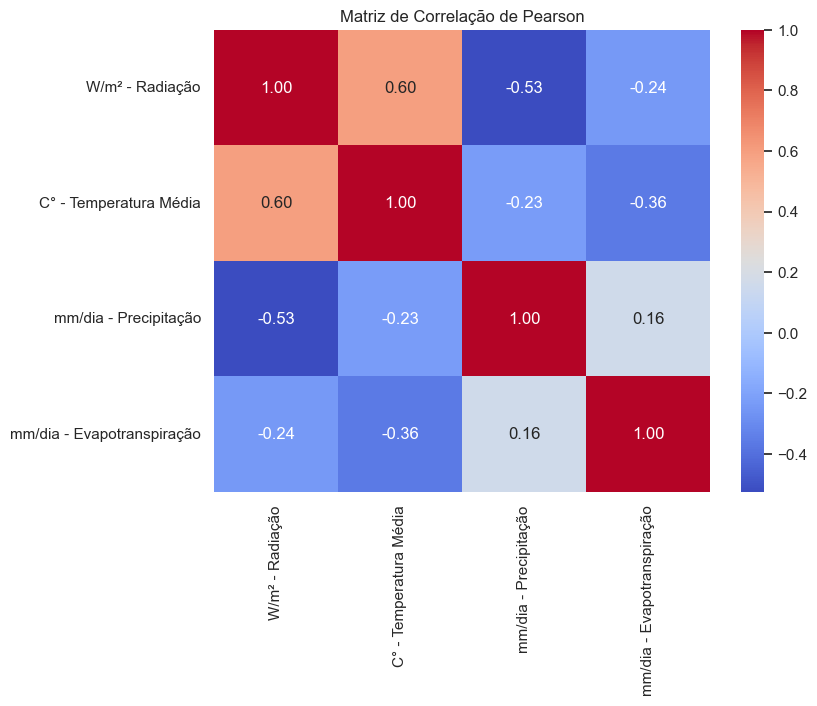

In [21]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlacao,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de Correlação de Pearson")
plt.show()

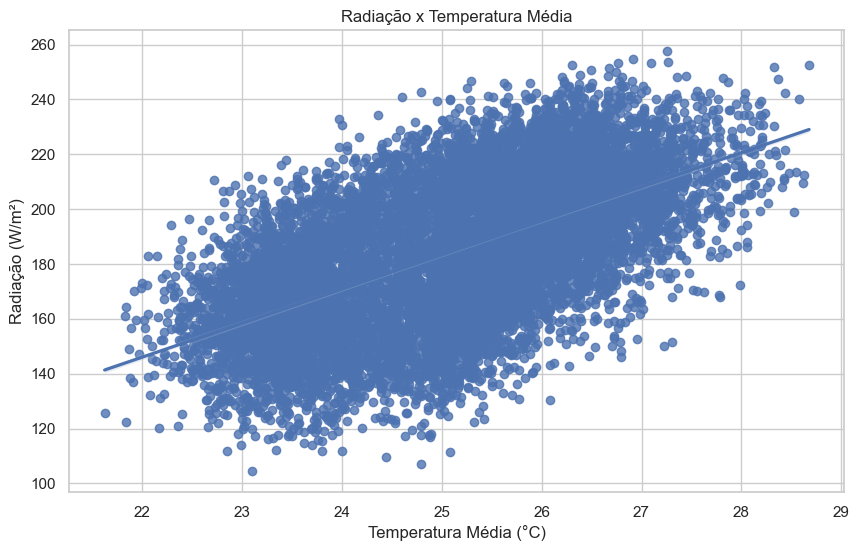

In [22]:
sns.regplot(
    x=dados["C° - Temperatura Média"],
    y=dados["W/m² - Radiação"]
)

plt.xlabel("Temperatura Média (°C)")
plt.ylabel("Radiação (W/m²)")
plt.title("Radiação x Temperatura Média")
plt.show()

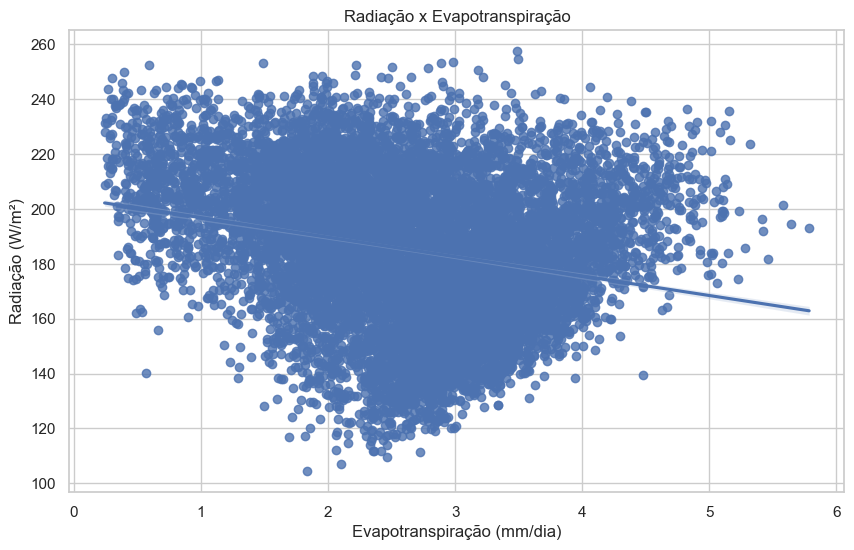

In [23]:
sns.regplot(
    x=dados["mm/dia - Evapotranspiração"],
    y=dados["W/m² - Radiação"]
)

plt.xlabel("Evapotranspiração (mm/dia)")
plt.ylabel("Radiação (W/m²)")
plt.title("Radiação x Evapotranspiração")
plt.show()

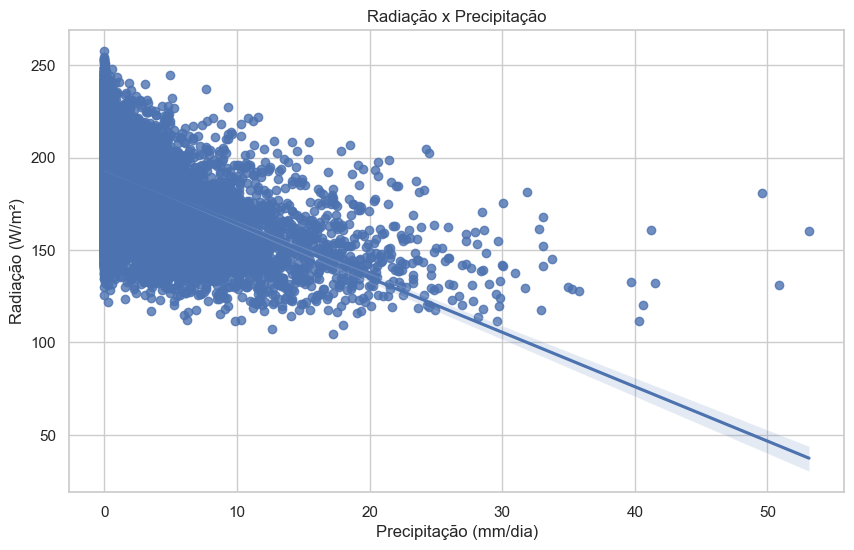

In [24]:
sns.regplot(
    x=dados["mm/dia - Precipitação"],
    y=dados["W/m² - Radiação"]
)

plt.xlabel("Precipitação (mm/dia)")
plt.ylabel("Radiação (W/m²)")
plt.title("Radiação x Precipitação")
plt.show()

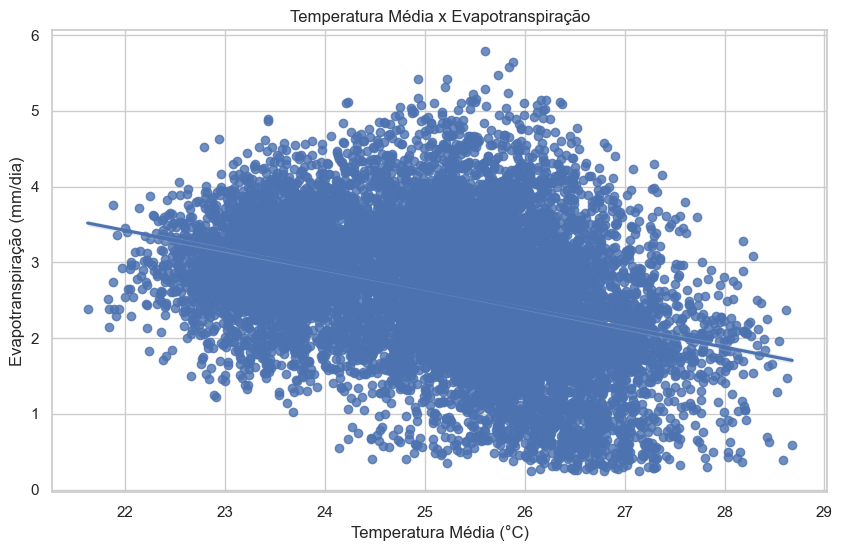

In [25]:
sns.regplot(
    x=dados["C° - Temperatura Média"],
    y=dados["mm/dia - Evapotranspiração"]
)

plt.xlabel("Temperatura Média (°C)")
plt.ylabel("Evapotranspiração (mm/dia)")
plt.title("Temperatura Média x Evapotranspiração")
plt.show()

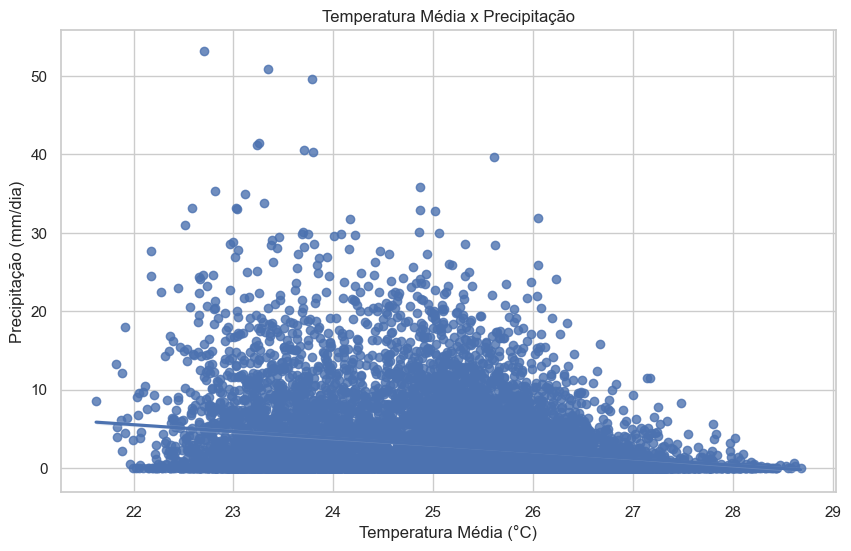

In [26]:
sns.regplot(
    x=dados["C° - Temperatura Média"],
    y=dados["mm/dia - Precipitação"]
)

plt.xlabel("Temperatura Média (°C)")
plt.ylabel("Precipitação (mm/dia)")
plt.title("Temperatura Média x Precipitação")
plt.show()

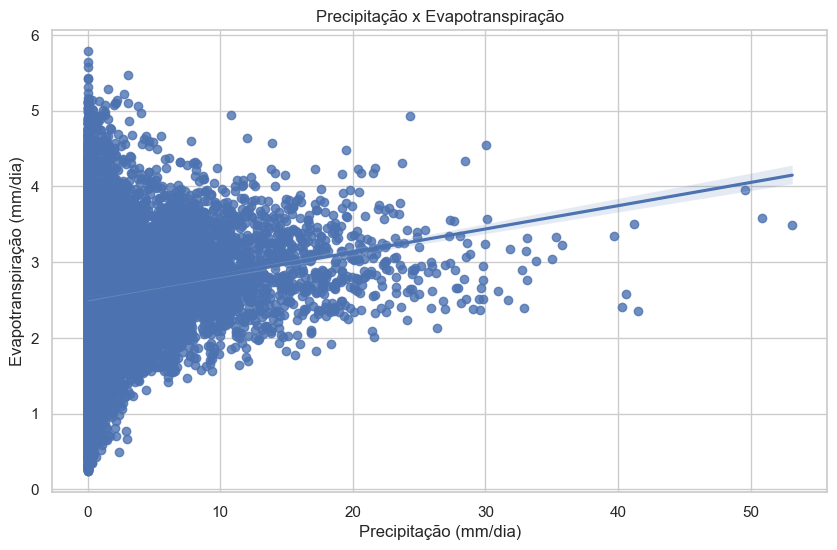

In [27]:
sns.regplot(
    x=dados["mm/dia - Precipitação"],
    y=dados["mm/dia - Evapotranspiração"]
)

plt.xlabel("Precipitação (mm/dia)")
plt.ylabel("Evapotranspiração (mm/dia)")
plt.title("Precipitação x Evapotranspiração")
plt.show()

In [28]:
X = dados[["C° - Temperatura Média"]]
y = dados["W/m² - Radiação"]

modelo_rt = LinearRegression()
modelo_rt.fit(X, y)

print("Coeficiente angular:", modelo_rt.coef_[0])
print("Intercepto:", modelo_rt.intercept_)
print("R²:", modelo_rt.score(X, y))

Coeficiente angular: 12.432745741951289
Intercepto: -127.51450797446745
R²: 0.35875020164262206


In [29]:
X = dados[["mm/dia - Evapotranspiração"]]
y = dados["W/m² - Radiação"]

modelo_re = LinearRegression()
modelo_re.fit(X, y)

print("Coeficiente angular:", modelo_re.coef_[0])
print("Intercepto:", modelo_re.intercept_)
print("R²:", modelo_re.score(X, y))

Coeficiente angular: -7.0922528014380415
Intercepto: 203.9369398807112
R²: 0.0593112347406769


In [30]:
X = dados[["mm/dia - Precipitação"]]
y = dados["W/m² - Radiação"]

modelo_rp = LinearRegression()
modelo_rp.fit(X, y)

print("Coeficiente angular:", modelo_rp.coef_[0])
print("Intercepto:", modelo_rp.intercept_)
print("R²:", modelo_rp.score(X, y))

Coeficiente angular: -2.943017055042723
Intercepto: 193.78534896411313
R²: 0.27739662688083544


In [31]:
X = dados[["C° - Temperatura Média"]]
y = dados["mm/dia - Evapotranspiração"]

modelo_te = LinearRegression()
modelo_te.fit(X, y)

print("Coeficiente angular:", modelo_te.coef_[0])
print("Intercepto:", modelo_te.intercept_)
print("R²:", modelo_te.score(X, y))

Coeficiente angular: -0.25703079322301997
Intercepto: 9.075646651658655
R²: 0.13003486537145303


In [32]:
X = dados[["C° - Temperatura Média"]]
y = dados["mm/dia - Precipitação"]

modelo_tp = LinearRegression()
modelo_tp.fit(X, y)

print("Coeficiente angular:", modelo_tp.coef_[0])
print("Intercepto:", modelo_tp.intercept_)
print("R²:", modelo_tp.score(X, y))

Coeficiente angular: -0.858666168358243
Intercepto: 24.444573787488743
R²: 0.05343073340179927


In [33]:
X = dados[["mm/dia - Precipitação"]]
y = dados["mm/dia - Evapotranspiração"]

modelo_pe = LinearRegression()
modelo_pe.fit(X, y)

print("Coeficiente angular:", modelo_pe.coef_[0])
print("Intercepto:", modelo_pe.intercept_)
print("R²:", modelo_pe.score(X, y))

Coeficiente angular: 0.030688233737705947
Intercepto: 2.518501465194418
R²: 0.02557942951618586


## 4. Correlação entre Variáveis

Nesta etapa foi realizada a análise de correlação entre as variáveis climáticas presentes no conjunto de dados, com o objetivo de identificar possíveis relações entre radiação solar, temperatura média, precipitação e evapotranspiração. Para isso, foi utilizado o coeficiente de correlação de Pearson, que mede a intensidade e a direção da relação linear entre duas variáveis.

A matriz de correlação mostrou que a radiação solar apresenta uma correlação positiva moderada com a temperatura média (r = 0.60). Esse resultado indica que, em geral, dias com temperaturas mais elevadas tendem a apresentar maior incidência de radiação solar. Essa relação é esperada, uma vez que maior radiação solar contribui para o aumento da temperatura do ar.

Por outro lado, foi observada uma correlação negativa moderada entre radiação e precipitação (r = -0.53). Isso indica que períodos com maior volume de chuva estão associados a menores níveis de radiação solar, o que pode ser explicado pela presença de nuvens que reduzem a incidência de radiação na superfície.

A relação entre radiação solar e evapotranspiração apresentou uma correlação negativa fraca (r = -0.24), indicando uma associação relativamente baixa entre essas variáveis no conjunto de dados analisado.

Entre as demais variáveis, a temperatura média apresentou correlação negativa fraca com a evapotranspiração (r = -0.36) e com a precipitação (r = -0.23). Já a relação entre precipitação e evapotranspiração mostrou uma correlação positiva muito fraca (r = 0.16), indicando que essas variáveis possuem baixa associação linear.

Além da análise de correlação, foram aplicados modelos de regressão linear simples para cada par de variáveis analisado. Os resultados indicaram que a relação mais significativa ocorre entre radiação solar e temperatura média, com coeficiente de determinação R² ≈ 0.36, indicando que cerca de 36% da variação da radiação pode ser explicada pela variação da temperatura média.

Para os demais pares de variáveis, os valores de R² foram baixos, indicando que a relação linear entre essas variáveis é limitada. Esses resultados sugerem que outros fatores climáticos ou ambientais podem influenciar o comportamento dessas variáveis.

De forma geral, os resultados mostram que a temperatura média é a variável que apresenta maior associação com a radiação solar, enquanto as demais variáveis apresentam relações mais fracas ou moderadas.